# IPPO Results

Reads directly from `Results/IPPO/*.csv` (columns: `test_reward, v2i_throughput_avg, miss_rate_avg`,
one row per test checkpoint). Locations are discovered from the CSV filenames present in
`Results/IPPO/`; the plots build one row per location found.

- **Normalized Return / V2I Throughput / CAM Delivery** -- one cell each, all 5 ratios overlaid per
  location.
- **G_max / G_min** -- one cell per greedy algorithm: `compute_greedy_baseline` (queue-drain
  heuristic) and `compute_greedy_baseline_reward` (true-VOI coordinate ascent, ported from
  `VoiPriorityGreedyOracleController`).
- **Comparison** -- the combined grid (one row per location x 3 metric columns) with greedy
  reference lines.

The G_max/G_min cells build a fresh `env` from the current `Configuration/env_params.py` (via
`build_env`) and call directly into `Helpers/stat_helper.py`, so the greedy reward, throughput, and
delivery reference values reflect whatever env parameters (bandwidth, cam size, etc.) are set at
the time the cell runs. `get_greedy_ref` looks up the live result for each `(loc, ratio)` pair from
`results_algo2`; each search takes several minutes per ratio, so re-run the cell after any env
parameter change to refresh the reference lines.


In [ ]:
import re
import glob
import csv
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

CSV_DIR = "Results/IPPO"
RATIOS = [("0.1", "0.9"), ("0.2", "0.8"), ("0.3", "0.7"), ("0.4", "0.6"), ("0.5", "0.5")]
CSV_RE = re.compile(r"loc(\d+)_16ag_4sc_NFF_cap([\d.]+)_miss([\d.]+)_trial(\d)_")

_cmap = matplotlib.colormaps["Blues"]
COLORS = [_cmap(0.35 + 0.60 * (i / 4)) for i in range(5)]  # light -> dark, low -> high ratio


def parse_csv(path):
    rewards, throughput, miss = [], [], []
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if row:
                rewards.append(float(row[0]))
                throughput.append(float(row[1]))
                miss.append(float(row[2]))
    return np.array(rewards), np.array(throughput), np.array(miss)


def mean_ci(trial_series):
    arr = np.stack(trial_series, axis=0)
    mean = arr.mean(axis=0)
    n = arr.shape[0]
    if n > 1:
        sem = stats.sem(arr, axis=0)
        ci = sem * stats.t.ppf(0.975, n - 1)
    else:
        ci = np.zeros_like(mean)
    return mean, ci


groups = {}
for f in glob.glob(CSV_DIR + "/*.csv"):
    m = CSV_RE.search(f)
    if not m:
        continue
    loc = int(m.group(1))
    cap, miss = m.group(2), m.group(3)
    groups.setdefault((loc, cap, miss), []).append(parse_csv(f))

# distinct locN values show up in Results/IPPO/*.csv filenames get plotted.
LOCS = sorted({loc for (loc, cap, miss) in groups})

print("loaded", sum(len(v) for v in groups.values()), "trial CSVs across", len(groups), "(loc, ratio) combos")
print("locations found:", LOCS)

## G_max / G_min — algorithm 1: `compute_greedy_baseline` (queue-drain heuristic)

In [ ]:
from Helpers.stat_helper import compute_greedy_baseline, compute_random_baseline
from Configuration.env_params import V2XParams
from Configuration.param_loader import apply_overrides, _load_json
from Environment.environment import Environ
from Environment.environment_utility import load_veh_pos, sample_veh_position_from_timestep

RATIO_FILE = {"0.1": "ratio_cap01_miss09", "0.2": "ratio_cap02_miss08", "0.3": "ratio_cap03_miss07",
              "0.4": "ratio_cap04_miss06", "0.5": "ratio_cap05_miss05"}
K16_PATH = "Environment/SUMOData/NFIG_k16.csv"

def build_env(loc, cap):
    p = V2XParams("SIG", float(loc))
    p.n_agent = 16
    p.n_veh_per_platoon = [2] * 16
    p.n_veh = 2 * 16
    p.agent_to_veh = p._build_agent_to_veh_mapping()
    full_train_data = load_veh_pos(K16_PATH)
    p.train_data = sample_veh_position_from_timestep(full_train_data, float(loc))
    overrides = _load_json(f"Configuration/env_ratios/{RATIO_FILE[cap]}.json", "Env config")
    apply_overrides(p, overrides)
    return p, Environ(p)

results_algo1 = {}
for loc in LOCS:
    for cap, miss in RATIOS:
        p, env = build_env(loc, cap)
        _, g_max = compute_greedy_baseline(env, [p.train_data], num_trials_per_location=1, verbose=False)
        _, g_min = compute_random_baseline(env, [p.train_data], num_trials_per_location=10, verbose=False)
        results_algo1[(loc, cap, miss)] = (g_min, g_max)
        print(f"loc={loc} {cap}/{miss}  G_min={g_min:.4f}  G_max={g_max:.4f}")

loc=0 0.1/0.9  G_min=-18.3113  G_max=8.9718
loc=0 0.2/0.8  G_min=-14.4619  G_max=17.9436
loc=0 0.3/0.7  G_min=-10.2878  G_max=26.9154
loc=0 0.4/0.6  G_min=-5.7352  G_max=35.8872
loc=0 0.5/0.5  G_min=-2.4252  G_max=44.8590
loc=9 0.1/0.9  G_min=-25.5127  G_max=5.8277
loc=9 0.2/0.8  G_min=-16.6977  G_max=11.6554
loc=9 0.3/0.7  G_min=-7.8635  G_max=17.4831
loc=9 0.4/0.6  G_min=0.4534  G_max=14.0604
loc=9 0.5/0.5  G_min=8.8843  G_max=23.2005


## G_max / G_min — algorithm 2: `compute_greedy_baseline_reward` (true-VOI coordinate ascent)

In [ ]:
from Helpers.stat_helper import compute_greedy_baseline_reward

results_algo2 = {}
for loc in LOCS:
    for cap, miss in RATIOS:
        p, env = build_env(loc, cap)
        _, g_max, g_max_throughput, g_max_delivery = compute_greedy_baseline_reward(
            env, [p.train_data], num_trials_per_location=1, verbose=False, return_metrics=True
        )
        _, g_min, g_min_throughput, g_min_delivery = compute_random_baseline(
            env, [p.train_data], num_trials_per_location=10, verbose=False, return_metrics=True
        )
        results_algo2[(loc, cap, miss)] = (g_min, g_max, g_max_throughput, g_max_delivery)
        print(f"loc={loc} {cap}/{miss}  G_min={g_min:.4f}  G_max={g_max:.4f}")
        print(f"    G_min  throughput={g_min_throughput/1e6:.2f}Mbps  delivery={g_min_delivery:.4f}")
        print(f"    G_max  throughput={g_max_throughput/1e6:.2f}Mbps  delivery={g_max_delivery:.4f}")

def get_greedy_ref(loc, cap, miss):
    return results_algo2[(loc, cap, miss)]


## Normalized Return

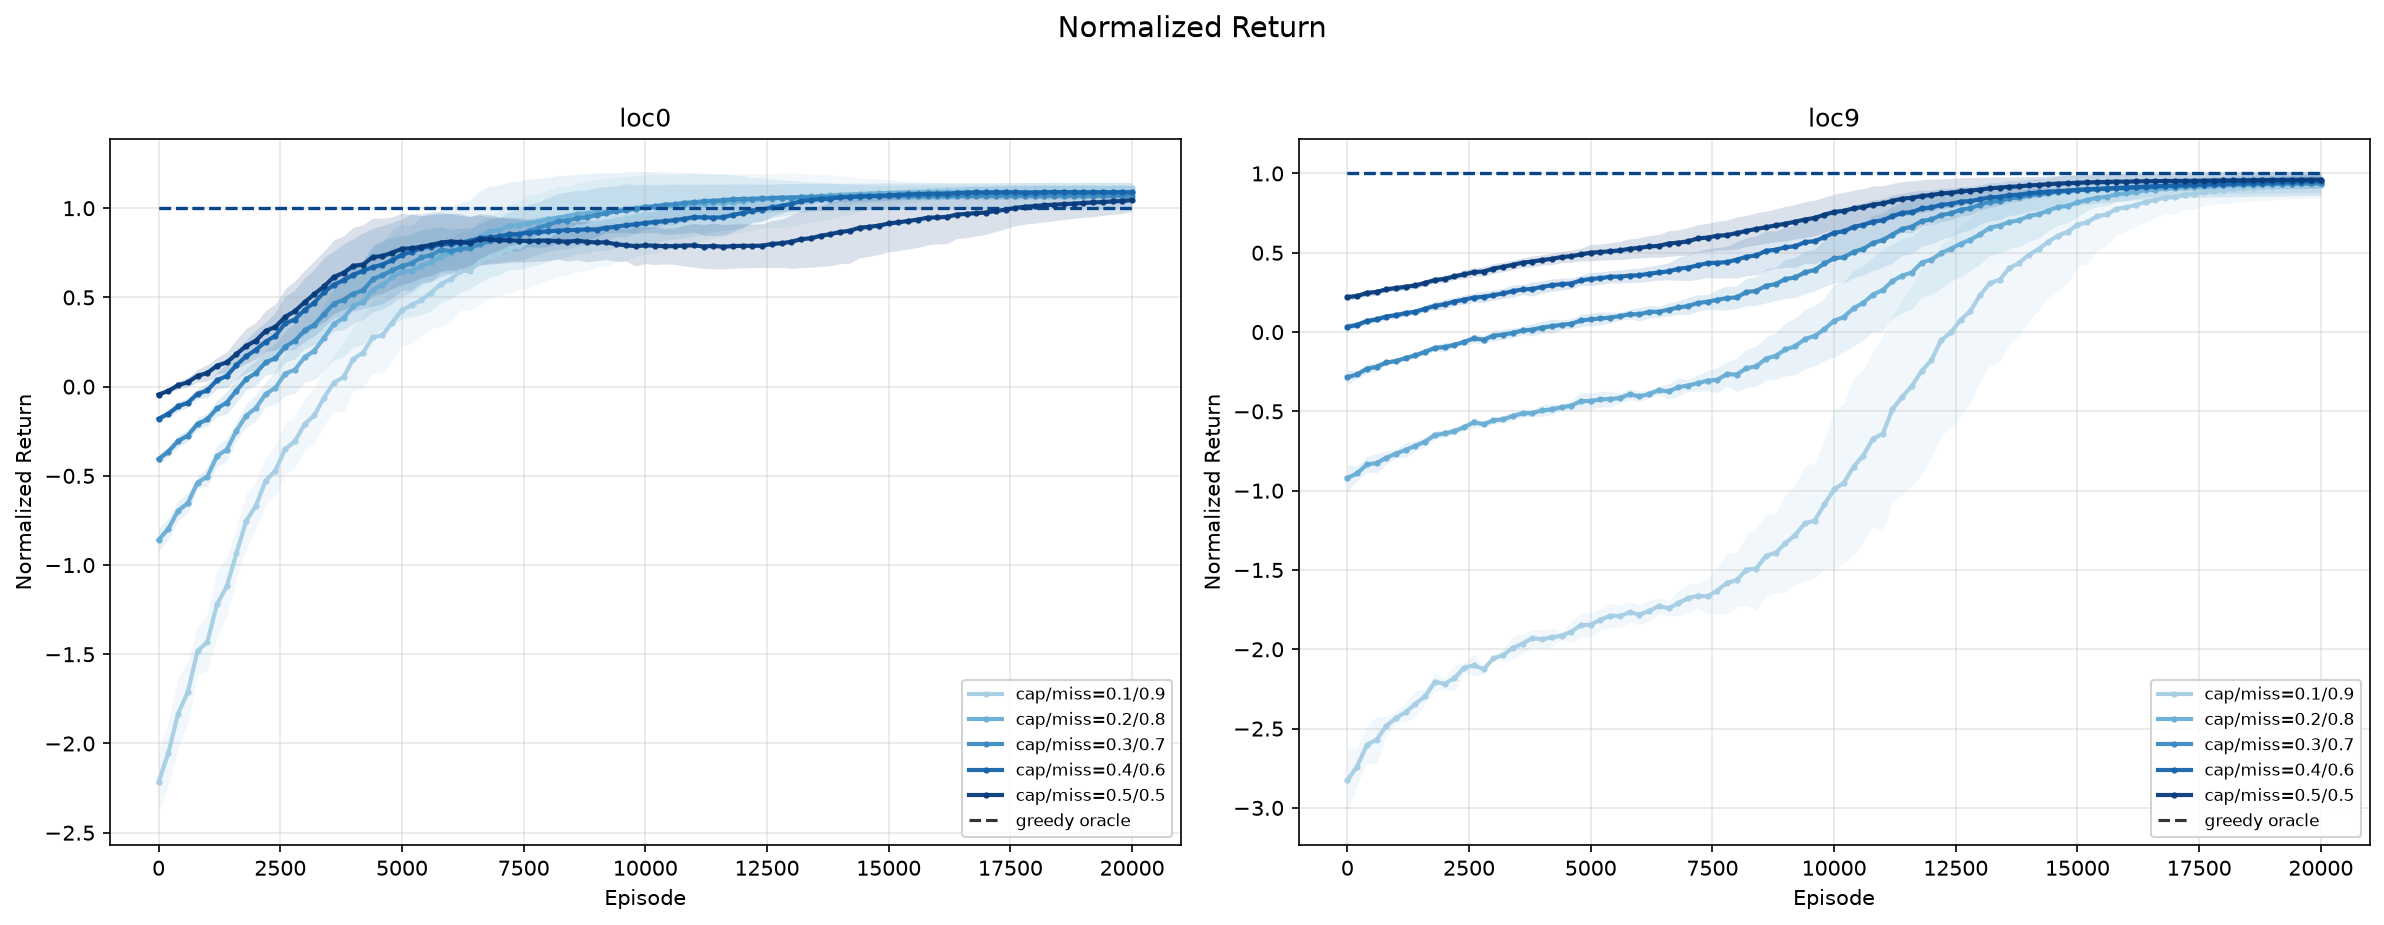

In [ ]:
def plot_metric(title, ylabel, series_fn, ref_fn, locs):
    n = len(locs)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 6))
    axes = np.atleast_1d(axes)
    for ax, loc in zip(axes, locs):
        for i, (cap, miss) in enumerate(RATIOS):
            trials = groups[(loc, cap, miss)]
            minlen = min(len(t[0]) for t in trials)
            series = series_fn(trials, minlen, loc, cap, miss)
            ref_val = ref_fn(loc, cap, miss)
            mean, ci = mean_ci(series)
            x = np.arange(minlen) * 200
            color = COLORS[i]
            ax.plot(x, np.full_like(x, ref_val, dtype=float), color=color, linestyle="--", linewidth=1.5, alpha=0.8)
            line, = ax.plot(x, mean, color=color, linewidth=2.0, marker="o", markersize=2.0, alpha=0.95,
                             label=f"cap/miss={cap}/{miss}")
            rgba = tuple(list(matplotlib.colors.to_rgb(color)) + [0.20])
            line.set_markerfacecolor(rgba); line.set_markeredgecolor(rgba)
            ax.fill_between(x, mean - ci, mean + ci, color=color, alpha=0.15, linewidth=0)
        ax.set_xlabel("Episode"); ax.set_ylabel(ylabel); ax.set_title(f"loc{loc}")
        ax.grid(True, alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, alpha=0.8))
        labels.append("greedy oracle")
        ax.legend(handles, labels, loc="lower right", fontsize=8, framealpha=0.85)
    fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

plot_metric("Normalized Return", "Normalized Return",
            lambda trials, minlen, loc, cap, miss: [t[0][:minlen] / get_greedy_ref(loc, cap, miss)[0] for t in trials],
            lambda loc, cap, miss: 1.0, LOCS)

## V2I Throughput

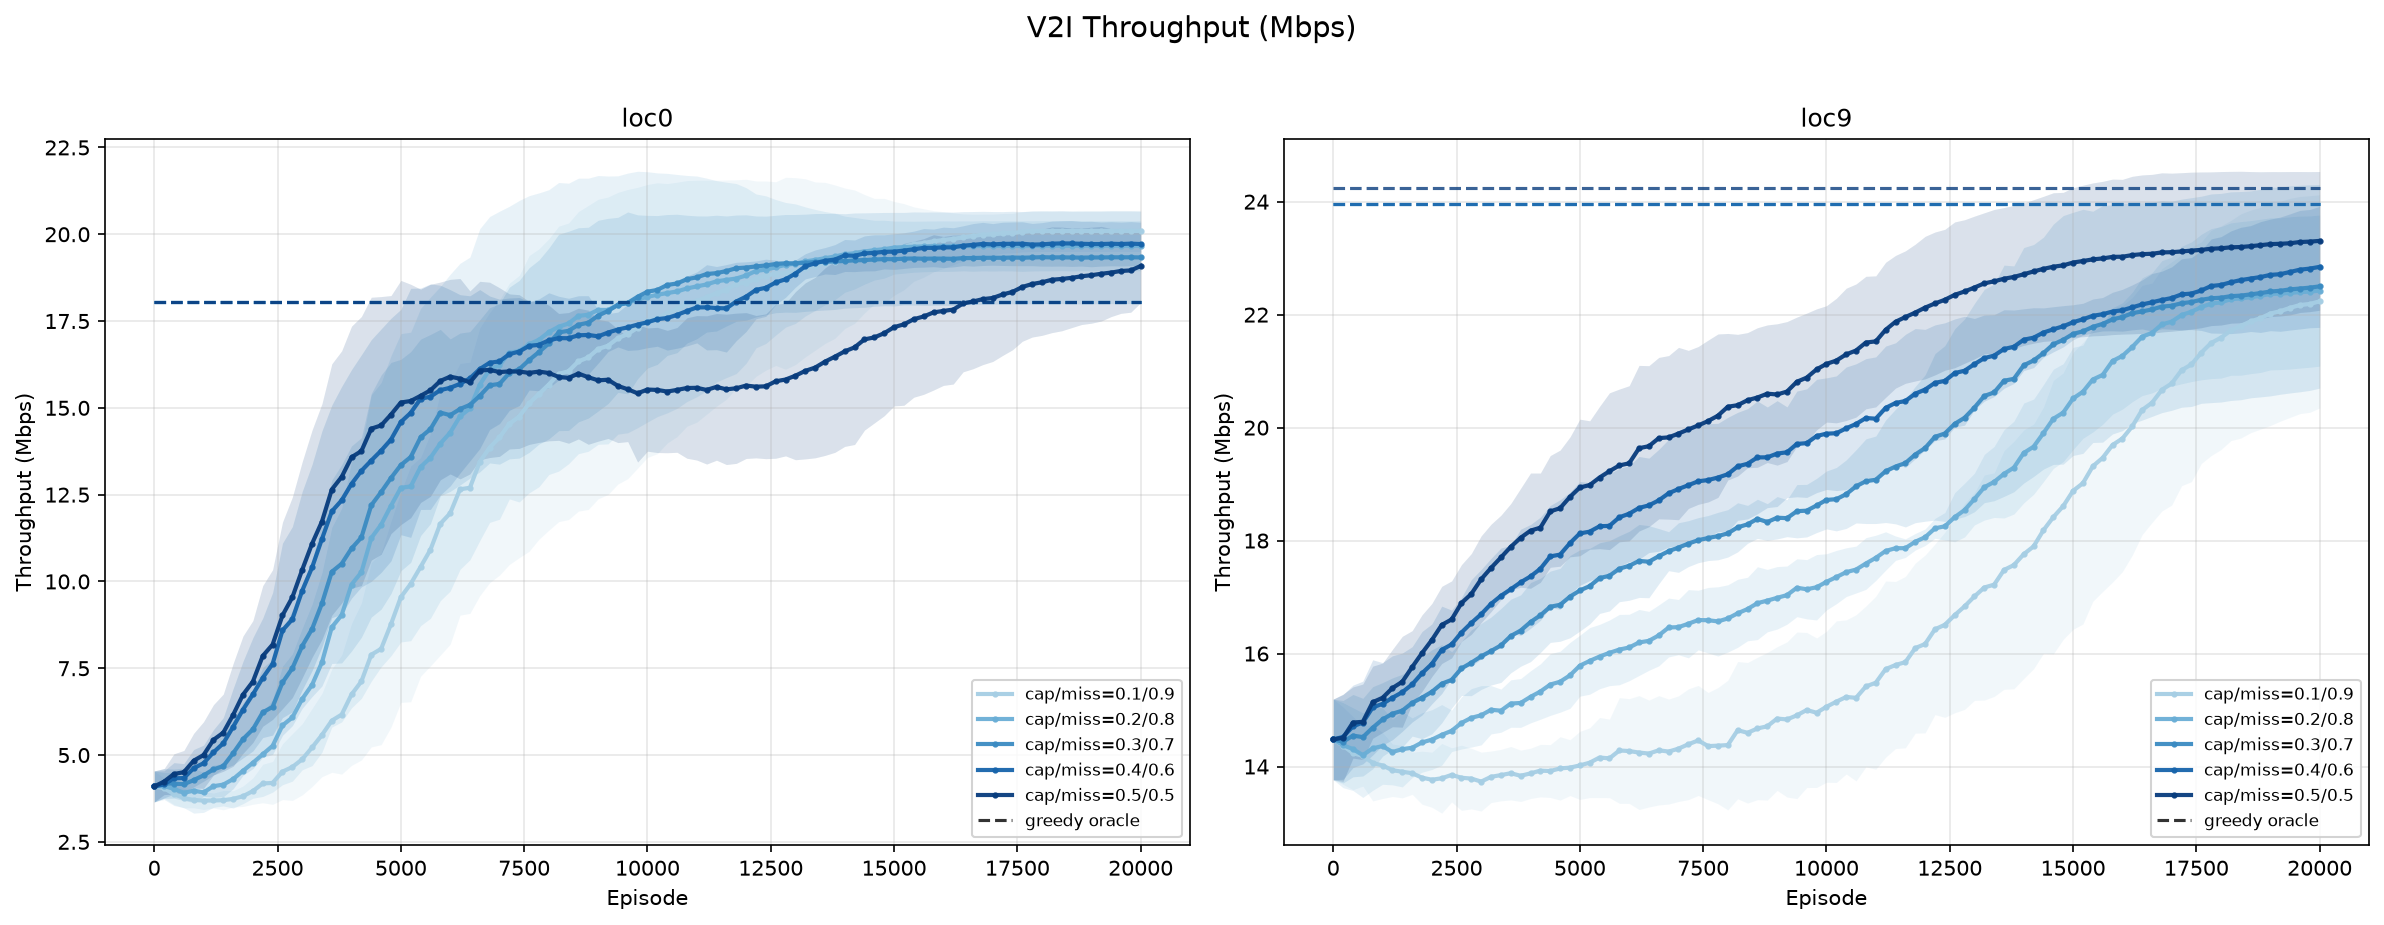

In [ ]:
plot_metric("V2I Throughput (Mbps)", "Throughput (Mbps)",
            lambda trials, minlen, loc, cap, miss: [t[1][:minlen] / 1e6 for t in trials],
            lambda loc, cap, miss: get_greedy_ref(loc, cap, miss)[1] / 1e6, LOCS)

## CAM Delivery Rate

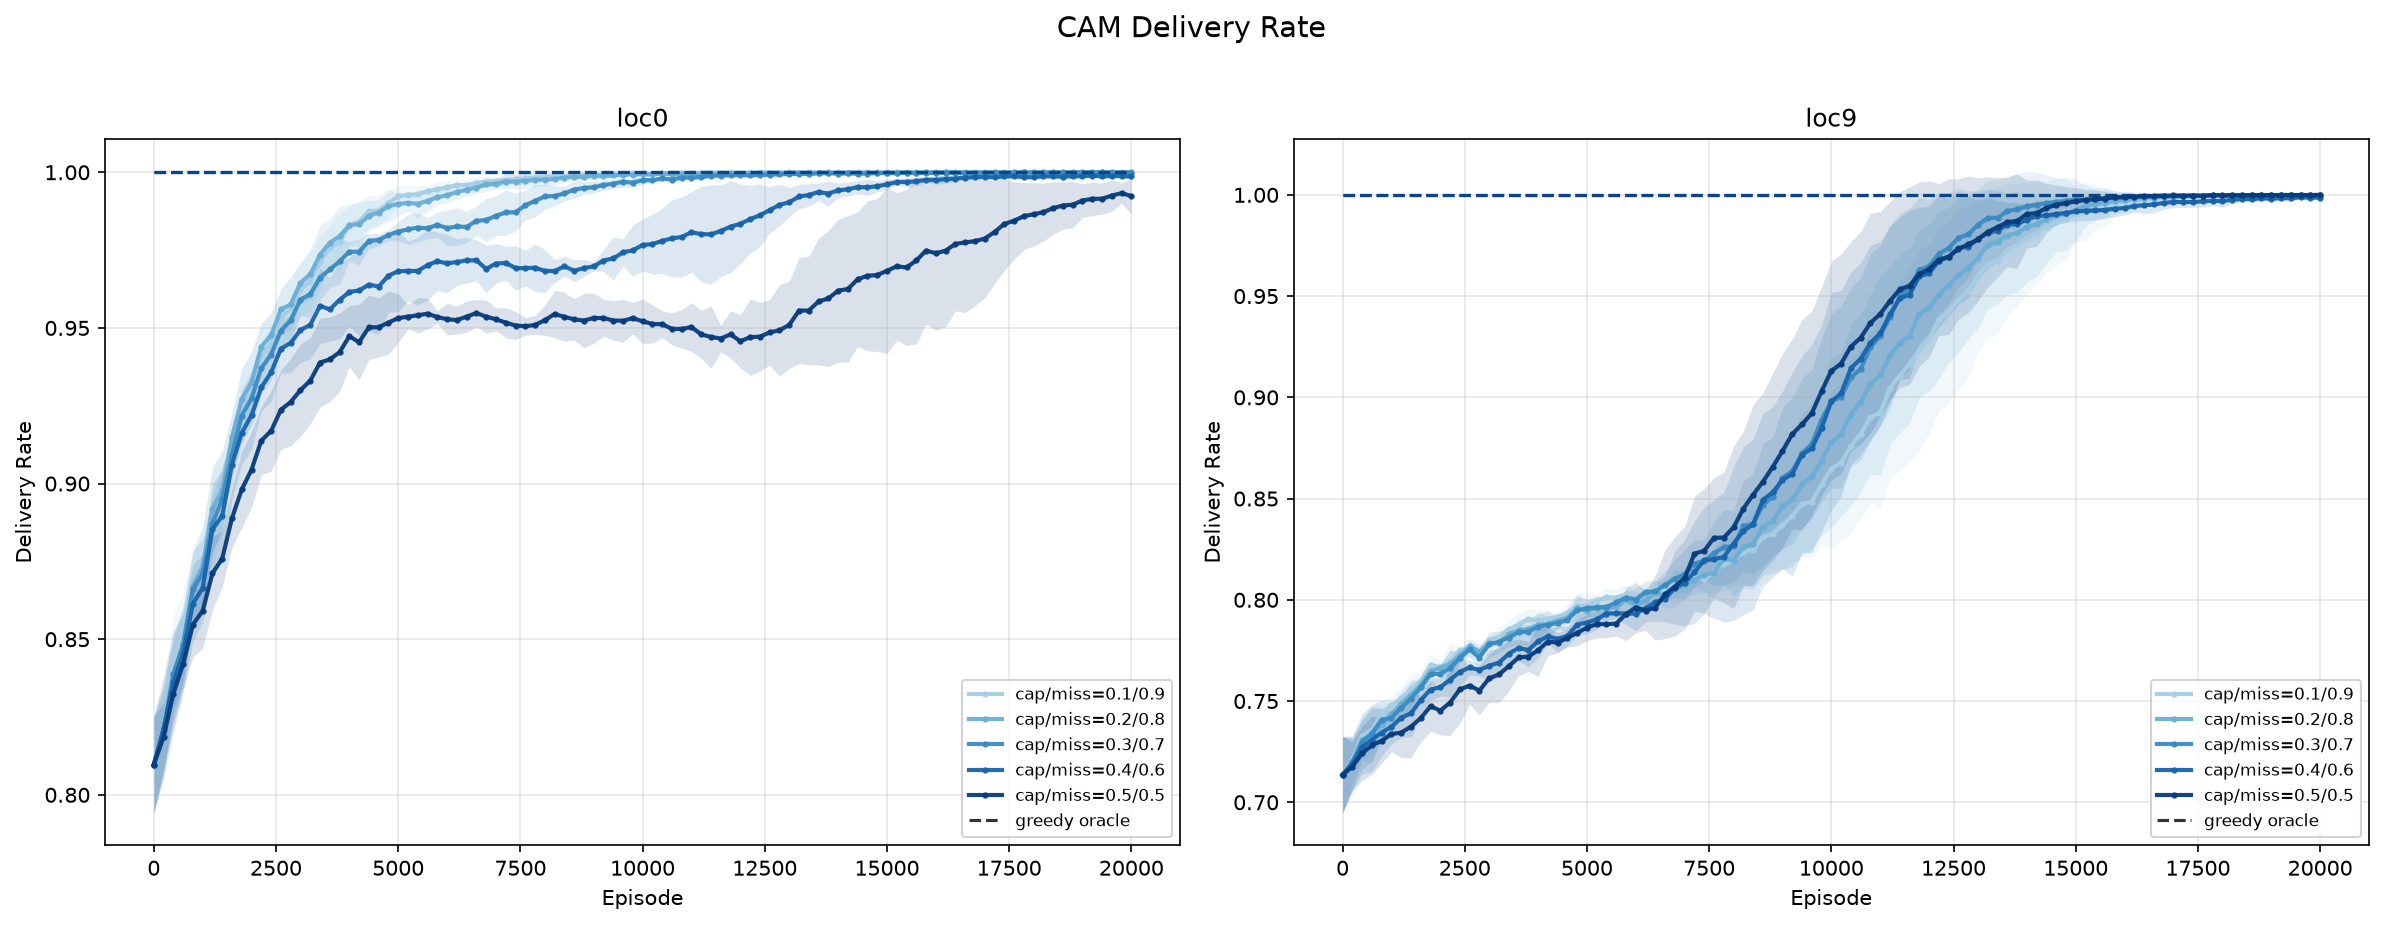

In [ ]:
plot_metric("CAM Delivery Rate", "Delivery Rate",
            lambda trials, minlen, loc, cap, miss: [1.0 - t[2][:minlen] for t in trials],
            lambda loc, cap, miss: 1.0, LOCS)

## Comparison — Return / Throughput / Delivery, all discovered locations

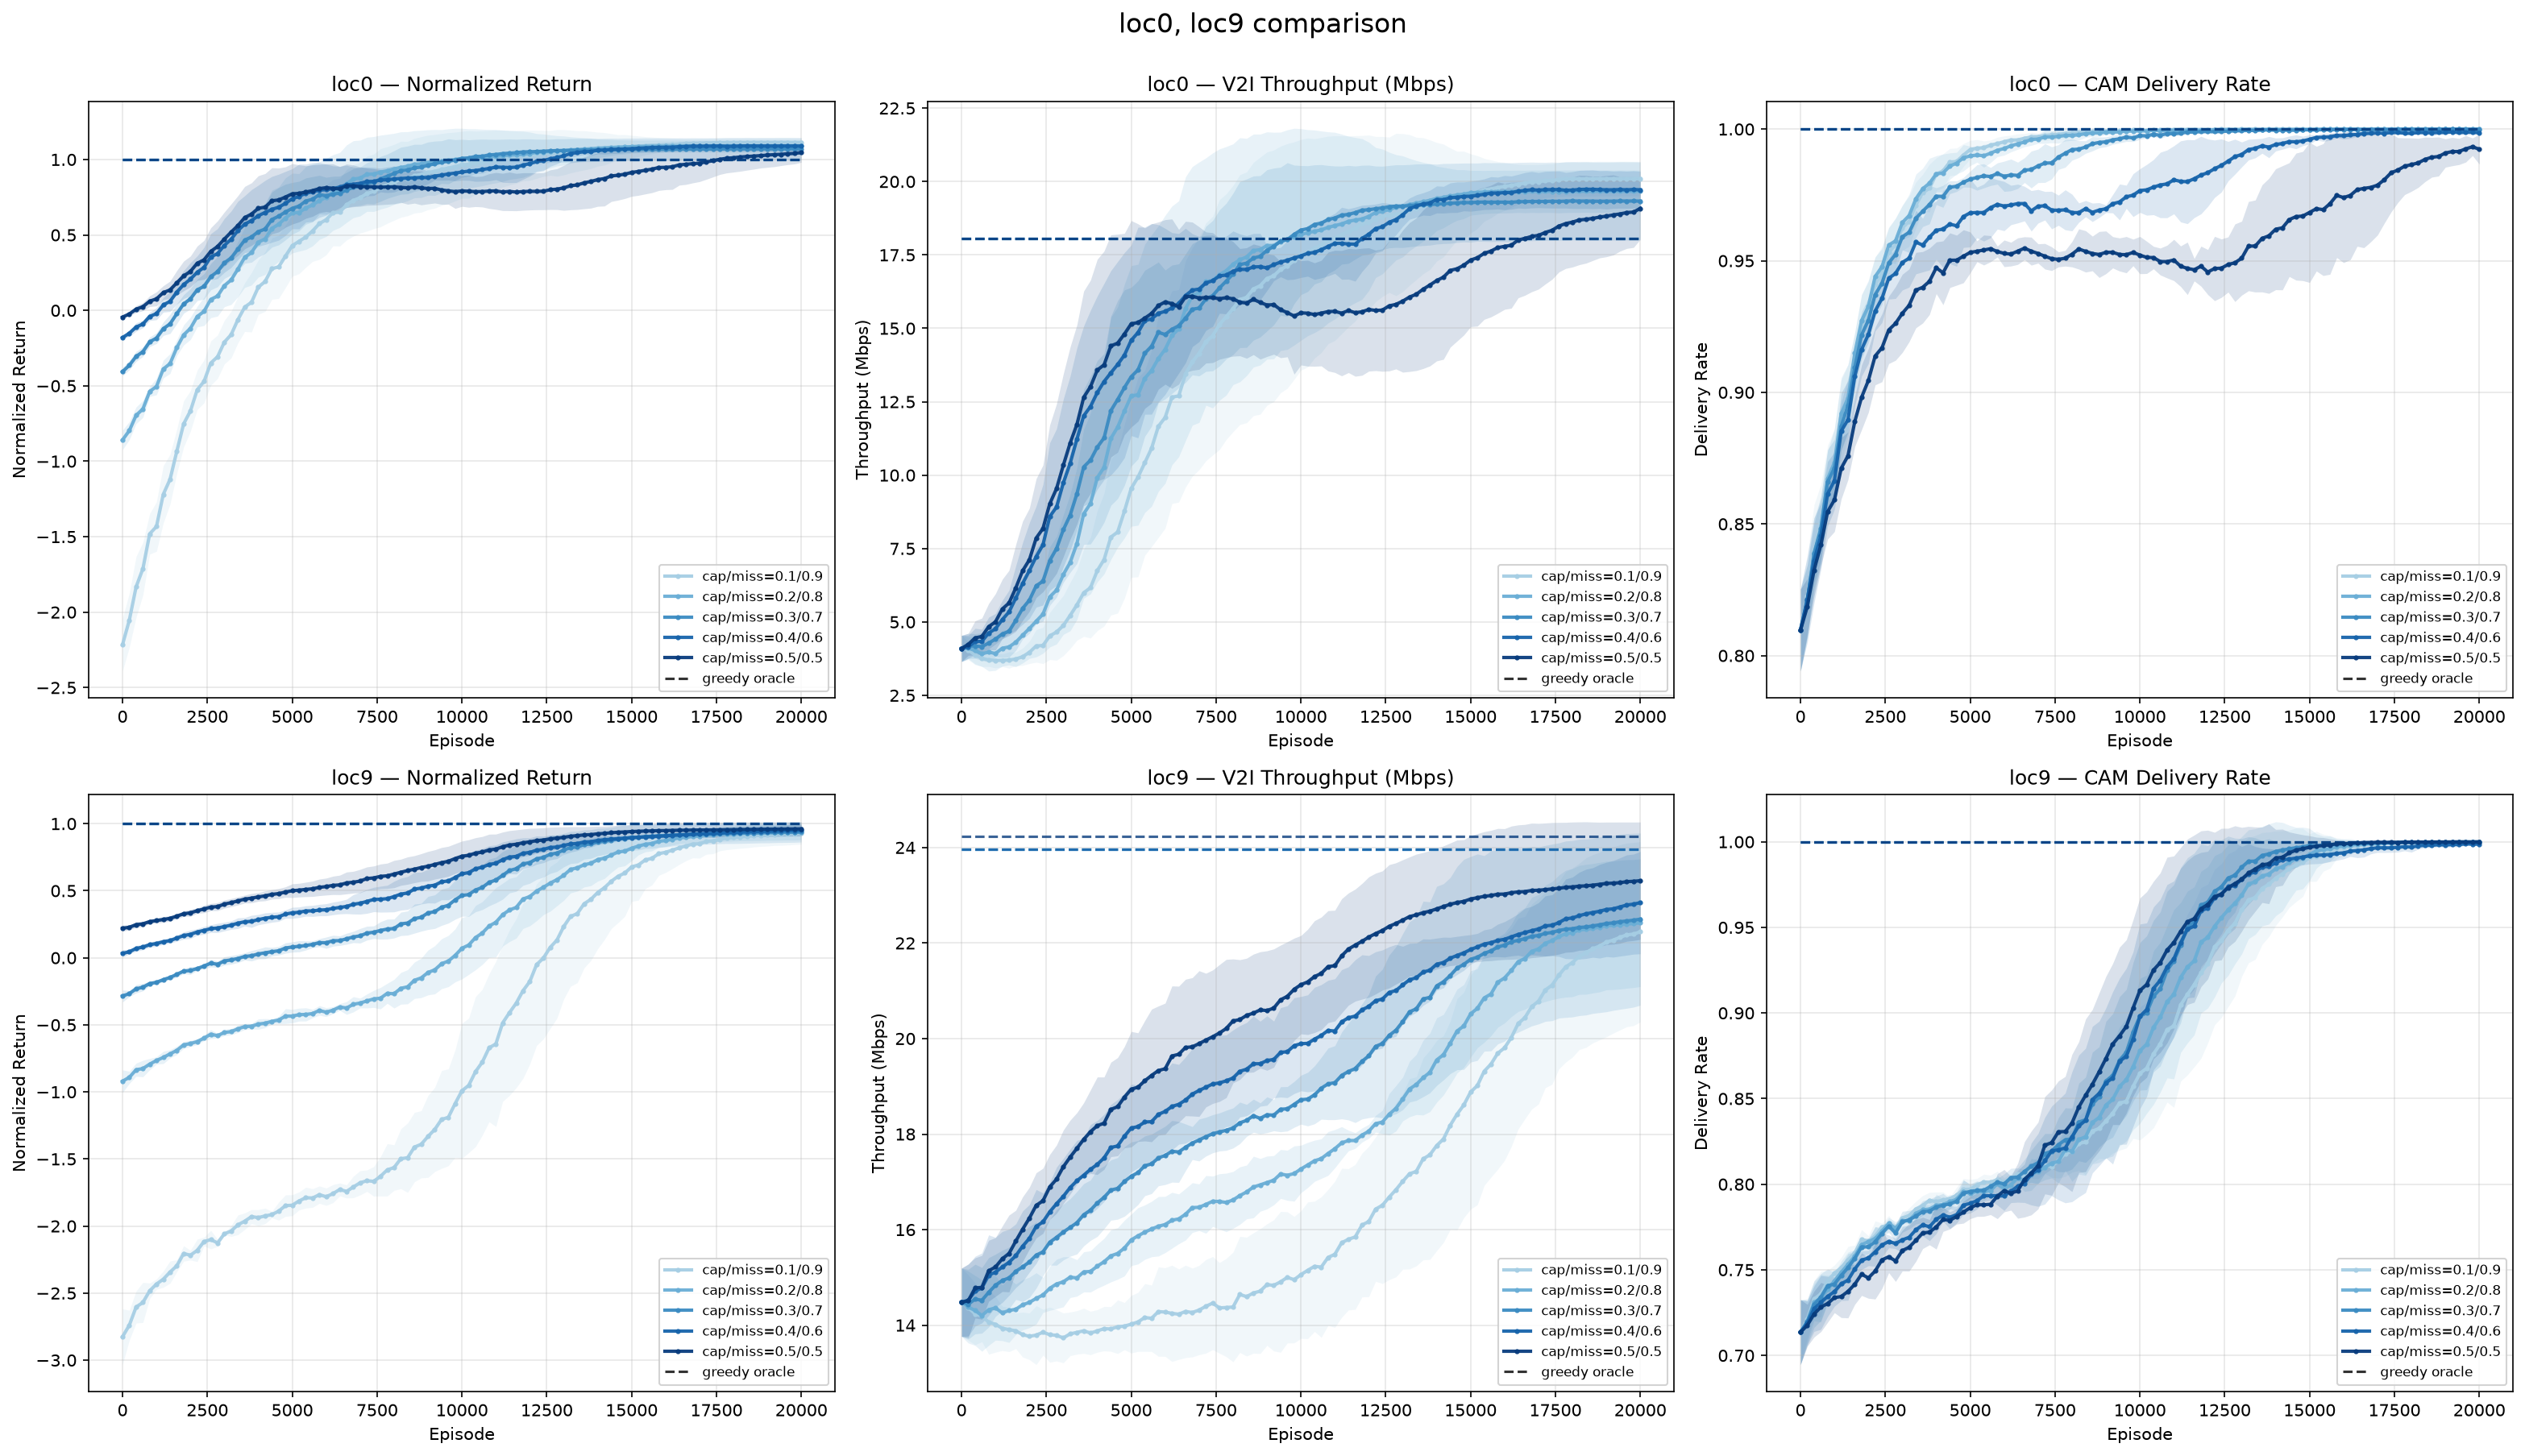

In [ ]:
# Grid: one row per location, 3 metric columns.
n_locs = len(LOCS)
fig, axes = plt.subplots(n_locs, 3, figsize=(21, 6 * n_locs))
axes = np.atleast_2d(axes)
panel_titles = ["Normalized Return", "V2I Throughput (Mbps)", "CAM Delivery Rate"]

for row, loc in enumerate(LOCS):
    for col, title in enumerate(panel_titles):
        ax = axes[row, col]
        for i, (cap, miss) in enumerate(RATIOS):
            trials = groups[(loc, cap, miss)]
            minlen = min(len(t[0]) for t in trials)
            if title == "CAM Delivery Rate":
                series = [1.0 - t[2][:minlen] for t in trials]; ref_val = 1.0; ylabel = "Delivery Rate"
            elif title == "Normalized Return":
                gmax_val = get_greedy_ref(loc, cap, miss)[0]
                series = [t[0][:minlen] / gmax_val for t in trials]; ref_val = 1.0; ylabel = "Normalized Return"
            else:
                gmax_val = get_greedy_ref(loc, cap, miss)[1] / 1e6
                series = [t[1][:minlen] / 1e6 for t in trials]; ref_val = gmax_val; ylabel = "Throughput (Mbps)"
            mean, ci = mean_ci(series)
            x = np.arange(minlen) * 200
            color = COLORS[i]
            ax.plot(x, np.full_like(x, ref_val, dtype=float), color=color, linestyle="--", linewidth=1.5, alpha=0.8)
            line, = ax.plot(x, mean, color=color, linewidth=2.0, marker="o", markersize=2.0, alpha=0.95,
                             label=f"cap/miss={cap}/{miss}")
            rgba = tuple(list(matplotlib.colors.to_rgb(color)) + [0.20])
            line.set_markerfacecolor(rgba); line.set_markeredgecolor(rgba)
            ax.fill_between(x, mean - ci, mean + ci, color=color, alpha=0.15, linewidth=0)
        ax.set_xlabel("Episode"); ax.set_ylabel(ylabel); ax.set_title(f"loc{loc} — {title}", fontsize=12)
        ax.grid(True, alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, alpha=0.8))
        labels.append("greedy oracle")
        ax.legend(handles, labels, loc="lower right", fontsize=8, framealpha=0.85)

fig.suptitle(f"{', '.join(f'loc{l}' for l in LOCS)} comparison", fontsize=16, y=1.0)
fig.tight_layout()
plt.show()